In [4]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import joblib
import cv2
import mediapipe as mp
import mlflow
from mlflow_utils import *


c:\Users\bedob\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## **Data Loading** ##

In [5]:
df = pd.read_csv('hand_landmarks_data.csv')
df.head()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,x19,y19,z19,x20,y20,z20,x21,y21,z21,label
0,262.669968,257.304901,-3.649205e-07,257.417542,247.109055,0.004224,246.882957,241.716827,0.005798,236.384537,...,223.345093,255.490692,-0.020450,215.043365,258.114746,-0.024577,208.006393,259.608673,-0.026722,call
1,83.351778,346.059113,-2.345265e-07,81.925037,328.562347,-0.011102,90.080132,311.535248,-0.021096,95.641823,...,132.451618,341.794434,-0.038175,142.773582,342.829254,-0.037336,152.431698,343.015991,-0.036136,call
2,187.756977,260.235492,-2.417307e-07,195.460579,241.506035,-0.000184,207.259529,223.674339,-0.009687,215.413628,...,250.301010,268.602938,-0.044068,262.425133,271.276638,-0.040469,272.989952,272.272231,-0.038301,call
3,114.976696,331.594238,-1.233261e-07,114.503494,320.549957,-0.002824,116.636627,310.080994,-0.008911,117.685066,...,145.195450,329.357544,-0.027622,151.053200,329.712341,-0.027863,155.990364,329.548828,-0.027723,call
4,188.795288,141.727867,-1.622995e-07,188.520905,127.947464,-0.002884,191.982880,111.010563,-0.008115,192.552521,...,226.696396,132.263248,-0.025113,234.831741,130.684147,-0.024087,241.587769,128.477188,-0.023486,call


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25675 entries, 0 to 25674
Data columns (total 64 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      25675 non-null  float64
 1   y1      25675 non-null  float64
 2   z1      25675 non-null  float64
 3   x2      25675 non-null  float64
 4   y2      25675 non-null  float64
 5   z2      25675 non-null  float64
 6   x3      25675 non-null  float64
 7   y3      25675 non-null  float64
 8   z3      25675 non-null  float64
 9   x4      25675 non-null  float64
 10  y4      25675 non-null  float64
 11  z4      25675 non-null  float64
 12  x5      25675 non-null  float64
 13  y5      25675 non-null  float64
 14  z5      25675 non-null  float64
 15  x6      25675 non-null  float64
 16  y6      25675 non-null  float64
 17  z6      25675 non-null  float64
 18  x7      25675 non-null  float64
 19  y7      25675 non-null  float64
 20  z7      25675 non-null  float64
 21  x8      25675 non-null  float64
 22

In [7]:
df.describe()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,z18,x19,y19,z19,x20,y20,z20,x21,y21,z21
count,25675.000000,25675.000000,2.567500e+04,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,...,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000
mean,201.958632,260.158527,1.272461e-07,202.517395,252.115322,-0.009465,202.862981,240.645966,-0.015946,203.025267,...,-0.024129,201.792374,227.455597,-0.033751,201.811275,227.802576,-0.032208,201.874802,227.807287,-0.028828
std,90.500333,76.533210,2.737932e-07,84.770933,75.384691,0.010376,80.412089,74.721921,0.013973,79.647588,...,0.015658,94.046497,77.231210,0.020453,93.664595,78.441253,0.020877,93.547017,79.963438,0.021136
min,-36.050926,45.722923,-2.029986e-06,7.184681,51.256840,-0.096630,25.114323,45.489950,-0.155846,23.446341,...,-0.201897,0.198635,20.146784,-0.286821,3.278137,32.158108,-0.286470,-4.537216,23.226204,-0.262047
25%,124.110329,205.815950,-5.243216e-08,130.535929,197.999625,-0.015199,136.711035,187.018583,-0.023020,138.905817,...,-0.030728,126.828913,172.720392,-0.042726,126.887403,172.345467,-0.041957,126.356627,172.083794,-0.039220
50%,199.667847,255.181793,1.497277e-07,199.979530,247.113892,-0.008737,200.092758,235.776978,-0.014231,200.482040,...,-0.020969,197.579865,221.781479,-0.029942,197.591736,222.381149,-0.028510,197.453270,222.485229,-0.025269
75%,266.428482,304.991663,2.989988e-07,261.147457,296.850769,-0.002783,255.876354,284.925993,-0.007134,254.622768,...,-0.013661,268.103920,273.190765,-0.019987,267.745743,274.196884,-0.017971,267.324657,275.805222,-0.014294
max,633.556020,781.674469,1.876254e-06,606.232386,751.869416,0.076365,598.541348,719.365010,0.094131,607.999801,...,0.031774,632.923029,779.419948,0.078105,638.134761,760.854103,0.104580,641.788521,760.554894,0.118668


In [8]:
df.shape

(25675, 64)

In [9]:
df['label'].value_counts()

label
three2             1653
palm               1649
four               1634
ok                 1592
stop_inverted      1567
call               1506
peace_inverted     1497
stop               1482
rock               1458
three              1456
peace              1441
like               1436
two_up_inverted    1371
two_up             1343
dislike            1295
one                1263
mute               1087
fist                945
Name: count, dtype: int64

## **Data Visulaization** 

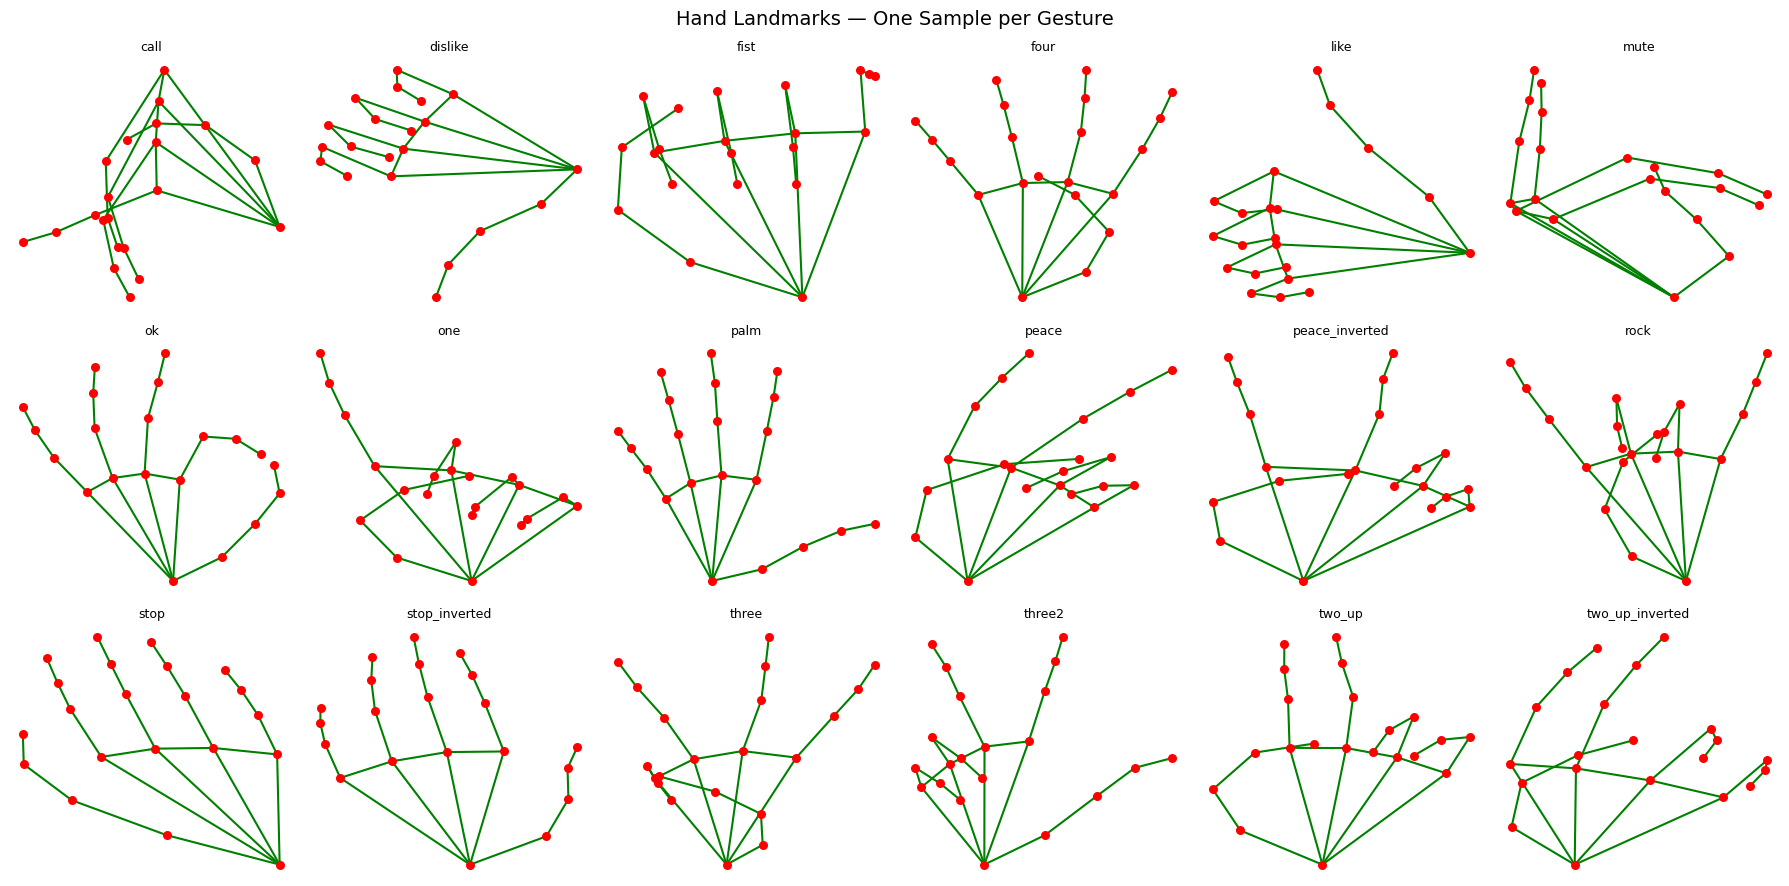

In [10]:
# MediaPipe hand connections (which landmarks to connect with lines)
connections = [
    (0,1),(1,2),(2,3),(3,4),        # Thumb
    (0,5),(5,6),(6,7),(7,8),        # Index
    (0,9),(9,10),(10,11),(11,12),   # Middle
    (0,13),(13,14),(14,15),(15,16), # Ring
    (0,17),(17,18),(18,19),(19,20), # Pinky
    (5,9),(9,13),(13,17)            # Palm
]

classes = df['label'].unique()

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
axes = axes.flatten()

for i, gesture in enumerate(sorted(classes)):
    # Get one sample from this gesture class
    row = df[df['label'] == gesture].iloc[0]

    # Get x and y coordinates (landmarks 1 to 21)
    x = [row[f'x{j}'] for j in range(1, 22)]
    y = [row[f'y{j}'] for j in range(1, 22)]

    ax = axes[i]

    # Draw skeleton lines
    for start, end in connections:
        ax.plot([x[start], x[end]], [y[start], y[end]], 'g-', linewidth=1.5)

    # Draw keypoints
    ax.scatter(x, y, c='red', s=30, zorder=5)

    ax.set_title(gesture, fontsize=9)
    ax.invert_yaxis()
    ax.axis('off')

plt.suptitle('Hand Landmarks — One Sample per Gesture', fontsize=14)
plt.tight_layout()
plt.show()


## **Data Preprocessing**

#### Handling null values 

In [11]:
df.isna().sum()

x1       0
y1       0
z1       0
x2       0
y2       0
        ..
z20      0
x21      0
y21      0
z21      0
label    0
Length: 64, dtype: int64

In [12]:
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values")

# Drop rows with missing values (if any)
df = df.dropna()
print("Shape after dropping nulls:", df.shape)


Missing values per column:
0 total missing values
Shape after dropping nulls: (25675, 64)


#### Handling the duplicated values 

In [13]:
df.duplicated().sum()

np.int64(0)

#### Normalize landmarks 

In [14]:
df_normalized = df.copy()

In [15]:
for i, row in df.iterrows():
    wrist_x = row['x1']
    wrist_y = row['y1']
    
    for j in range(1,22):
        
        df_normalized.at[i,f'x{j}'] = row[f'x{j}'] - wrist_x
        df_normalized.at[i,f'y{j}'] = row[f'y{j}'] - wrist_y
        
    mid_x = df_normalized.at[i, 'x13']
    mid_y = df_normalized.at[i, 'y13']
    
    for j in range(1,22):
        if mid_x != 0:
            df_normalized.at[i,f'x{j}'] = df_normalized.at[i,f'x{j}'] / mid_x
        if mid_y != 0:
            df_normalized.at[i,f'y{j}'] = df_normalized.at[i,f'y{j}'] / mid_y
                

#### Encoding labels 

In [16]:
le = LabelEncoder()

df_normalized['label_encoded'] = le.fit_transform(df_normalized['label'])

In [17]:
print("Classes : " ,list(le.classes_))

Classes :  ['call', 'dislike', 'fist', 'four', 'like', 'mute', 'ok', 'one', 'palm', 'peace', 'peace_inverted', 'rock', 'stop', 'stop_inverted', 'three', 'three2', 'two_up', 'two_up_inverted']


In [18]:
print("Encoded as:", list(range(len(le.classes_))))

Encoded as: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]


#### Split Features and target 

In [19]:
feature_cols = [f'x{i}' for i in range(1, 22)] + \
               [f'y{i}' for i in range(1, 22)] + \
               [f'z{i}' for i in range(1, 22)]

X = df_normalized[feature_cols]
y = df_normalized['label_encoded']

print("Features shape:", X.shape)
print("Labels shape:", y.shape)


Features shape: (25675, 63)
Labels shape: (25675,)


#### Train / Test split 

In [20]:
print("length of data " , len(df_normalized))

length of data  25675


In [21]:
X_train , X_test , y_train , y_test = train_test_split(X, y , test_size=0.2, random_state=42 ,stratify=y)

print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

Training set shape: (20540, 63) (20540,)
Testing set shape: (5135, 63) (5135,)


## **Model Training** 

In [20]:
models = {
    'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN'           : KNeighborsClassifier(n_neighbors=5),
    'LR'            : Pipeline([
                        ('scaler', StandardScaler()),
                        ('lr', LogisticRegression(max_iter=1000, random_state=42))
                      ])
}

In [ ]:
results = {}

for name , model in models.items():
    print(f"trainig the mdoel {name} ... ")
    
    #training the model
    model.fit(X_train , y_train)
    
    #predicting the test set
    y_pred = model.predict(X_test)
    
    #evaluating the model accuracy only for fast evaluation
    acc= accuracy_score(y_test , y_pred)
    results[name] = acc
    
    
    print(f" {name} Accuracy: {acc * 100:.2f}%")
    

trainig the mdoel Random Forest ... 
 Random Forest Accuracy: 96.51%
                 precision    recall  f1-score   support

           call       0.99      0.99      0.99       301
        dislike       0.98      0.98      0.98       259
           fist       0.99      0.99      0.99       189
           four       0.96      0.96      0.96       327
           like       0.98      0.97      0.97       287
           mute       0.96      0.97      0.97       217
             ok       0.99      0.99      0.99       318
            one       0.95      0.96      0.95       253
           palm       0.93      0.94      0.93       330
          peace       0.94      0.92      0.93       288
 peace_inverted       0.99      0.95      0.97       299
           rock       1.00      0.98      0.99       292
           stop       0.92      0.95      0.93       296
  stop_inverted       0.98      0.98      0.98       314
          three       0.99      0.97      0.98       291
         three2   

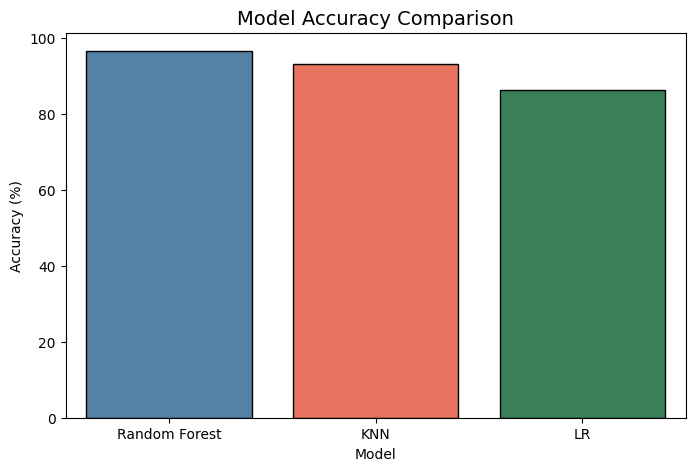

In [22]:
plt.figure(figsize=(8, 5))
sns.barplot(x=list(results.keys()), y=[v * 100 for v in results.values()],
            palette=['steelblue', 'tomato', 'seagreen'], edgecolor='black',hue=list(results.keys()), dodge=False)
plt.title('Model Accuracy Comparison', fontsize=14)
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.show()

## **Model Evaluation**

In [33]:
evaluation_metrics = {}

for name, model in models.items():
    
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test,y_pred)
    precision  = precision_score(y_test,y_pred,average='weighted',zero_division=0)
    recall= recall_score(y_test,y_pred,average='weighted',zero_division=0)
    F1_score = f1_score(y_test,y_pred,average='weighted',zero_division=0)
    
    evaluation_metrics[name] = {
        'Accuracy':accuracy,
        'precision':precision,
        'recall':recall,
        'f1_score':F1_score
        
    }
    print(f"{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")
    print(f"Accuracy:  {accuracy*100:.2f}%")
    print(f"Precision: {precision*100:.2f}%")
    print(f"Recall:    {recall*100:.2f}%")
    print(f"F1-Score:  {F1_score*100:.2f}%")

Model: Random Forest
Accuracy:  96.51%
Precision: 96.55%
Recall:    96.51%
F1-Score:  96.52%
Model: KNN
Accuracy:  93.01%
Precision: 93.08%
Recall:    93.01%
F1-Score:  93.02%
Model: LR
Accuracy:  86.31%
Precision: 86.28%
Recall:    86.31%
F1-Score:  86.23%


#### Table comparison between all models with all metrics 

In [35]:
eval_df = pd.DataFrame(evaluation_metrics).T*100
eval_df = eval_df.round(2)
eval_df.head()

,Accuracy,precision,recall,f1_score
Random Forest,96.51,96.55,96.51,96.52
KNN,93.01,93.08,93.01,93.02
LR,86.31,86.28,86.31,86.23


#### Visualiztion

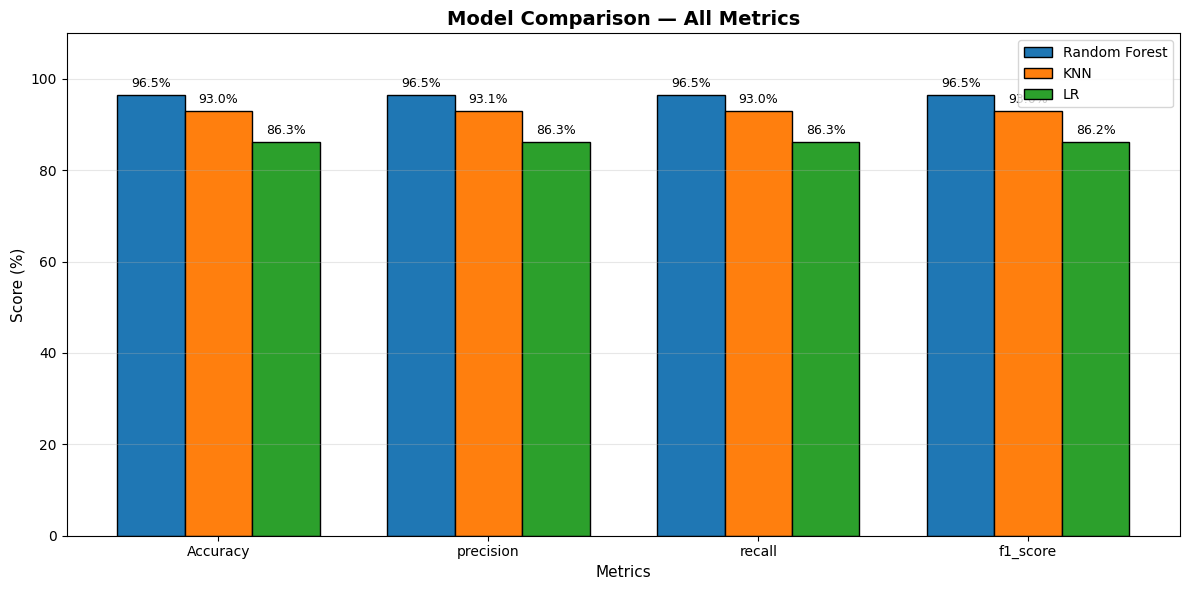

In [40]:
metrics = ['Accuracy', 'precision', 'recall', 'f1_score']
models_names = list(evaluation_metrics.keys())
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

for i, model_name in enumerate(models_names):
    values = [evaluation_metrics[model_name][metric]*100 for metric in metrics]
    bars = ax.bar(x + i*width, values, width, label=model_name, edgecolor='black')

    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Metrics', fontsize=11)
ax.set_ylabel('Score (%)', fontsize=11)
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 110)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#### Detailed report with Classification Report 

In [ ]:
for name , model in models.items():
    y_pred  = model.predict(X_test)
    
    print(f"{'='*50}")
    print(f"report of : {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    

report of : Random Forest
                 precision    recall  f1-score   support

           call       0.99      0.99      0.99       301
        dislike       0.98      0.98      0.98       259
           fist       0.99      0.99      0.99       189
           four       0.96      0.96      0.96       327
           like       0.98      0.97      0.97       287
           mute       0.96      0.97      0.97       217
             ok       0.99      0.99      0.99       318
            one       0.95      0.96      0.95       253
           palm       0.93      0.94      0.93       330
          peace       0.94      0.92      0.93       288
 peace_inverted       0.99      0.95      0.97       299
           rock       1.00      0.98      0.99       292
           stop       0.92      0.95      0.93       296
  stop_inverted       0.98      0.98      0.98       314
          three       0.99      0.97      0.98       291
         three2       0.97      0.99      0.98       331
    

#### Finding The best model 

In [58]:
best_accuarcy = eval_df['Accuracy'].idxmax()
best_precision = eval_df['precision'].idxmax()
best_recall = eval_df['recall'].idxmax()
best_f1 = eval_df['f1_score'].idxmax()


print("\n" + "="*60)
print("BEST PERFORMING MODELS")
print("="*60)
print(f"Best Accuracy:  {best_accuarcy} ({eval_df.loc[best_accuarcy, 'Accuracy']:.2f}%)")
print(f"Best Precision: {best_precision} ({eval_df.loc[best_precision, 'precision']:.2f}%)")
print(f"Best Recall:    {best_recall} ({eval_df.loc[best_recall, 'recall']:.2f}%)")
print(f"Best F1-Score:  {best_f1} ({eval_df.loc[best_f1, 'f1_score']:.2f}%)")



BEST PERFORMING MODELS
Best Accuracy:  Random Forest (96.51%)
Best Precision: Random Forest (96.55%)
Best Recall:    Random Forest (96.51%)
Best F1-Score:  Random Forest (96.52%)


#### **The Best model is Random Forest with overall accuracy 96.51%**

## **part2 Output video**

#### Save the model

In [57]:
best_model_name = 'Random Forest'

best_model = models[best_model_name]

model_path = 'best_model.pkl'

joblib.dump(best_model,model_path)

print("The model is saved successfully !")

The model is saved successfully !


#### Save the Encoder

In [59]:
encoder_path = 'label_encoder.pkl'
joblib.dump(le,encoder_path)

print("the encoder is saved successfully !")

the encoder is saved successfully !


#### Loading the model for use

In [24]:
model = joblib.load('best_model.pkl')
print("The model is loaded successfully ") 

le = joblib.load('label_encoder.pkl')
print("The Encoder is loaded successfully ") 


The model is loaded successfully 
The Encoder is loaded successfully 


#### Make a prediction 

In [25]:
test_sample  = X_test.iloc[0:1]

predicition_number = model.predict(test_sample)[0]

pred_label  = le.inverse_transform([predicition_number])[0]
print(pred_label)

palm


In [26]:
# Get probability for each class
probabilities = model.predict_proba(test_sample)[0]

# Find highest probability
max_prob = probabilities.max()
predicted_class = probabilities.argmax()
predicted_gesture = le.inverse_transform([predicted_class])[0]

print(f"Gesture: {predicted_gesture}")
print(f"Confidence: {max_prob*100:.2f}%")

Gesture: palm
Confidence: 93.00%


## process the video frame by frame 

In [23]:
from mediapipe.tasks import python
from mediapipe.tasks.python import vision


# Path to downloaded hand landmarker model
model_path = "hand_landmarker.task"  

# Create base options
base_options = python.BaseOptions(model_asset_path=model_path)

# Configure hand landmarker
options = vision.HandLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,  # use IMAGE if single image
    num_hands=1,
    min_hand_detection_confidence=0.7,
    min_tracking_confidence=0.5
)

# Create the hand landmarker
hand_landmarker = vision.HandLandmarker.create_from_options(options)

print("MediaPipe HandLandmarker initialized successfully")

MediaPipe HandLandmarker initialized successfully


In [ ]:
from collections import deque
from scipy import stats

def normalize_landmarks(hand_landmarks, frame_w, frame_h):

    coords = []
    for lm in hand_landmarks:
        coords.append((lm.x * frame_w, lm.y * frame_h, lm.z))

    wrist_x, wrist_y = coords[0][0], coords[0][1]

    # Recenter around the wrist
    centered = []
    for (x, y, z) in coords:
        centered.append((x - wrist_x, y - wrist_y, z))

    # Scale by middle finger tip (landmark 12)
    mid_x = centered[12][0]
    mid_y = centered[12][1]

    normalized = []
    for (x, y, z) in centered:
        nx = x / mid_x if mid_x != 0 else x
        ny = y / mid_y if mid_y != 0 else y
        normalized.append((nx, ny, z))

    # Build feature vector: x1..x21, y1..y21, z1..z21
    feature = []
    feature += [p[0] for p in normalized]
    feature += [p[1] for p in normalized]
    feature += [p[2] for p in normalized]
    return feature


def get_stable_prediction(prediction_window):
    """Returns the mode (most frequent) prediction from the recent window."""
    if len(prediction_window) == 0:
        return None, 0.0
    mode_result = stats.mode(prediction_window, keepdims=True)
    return mode_result.mode[0], mode_result.count[0] / len(prediction_window)


HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (0,9),(9,10),(10,11),(11,12),
    (0,13),(13,14),(14,15),(15,16),
    (0,17),(17,18),(18,19),(19,20),
    (5,9),(9,13),(13,17)
]

def draw_hand_skeleton(frame, hand_landmarks, frame_w, frame_h):
    points = []
    for lm in hand_landmarks:
        px = int(lm.x * frame_w)
        py = int(lm.y * frame_h)
        points.append((px, py))

    for start, end in HAND_CONNECTIONS:
        cv2.line(frame, points[start], points[end], (0, 255, 0), 2)

    for (px, py) in points:
        cv2.circle(frame, (px, py), 5, (0, 0, 255), -1)

    return frame


Helper functions defined successfully


## Process video frame by frame

In [ ]:
input_video_path = "test_abdallah2.mp4"
output_video_path = "output_video.avi"
WINDOW_SIZE = 15

base_options = python.BaseOptions(model_asset_path="hand_landmarker.task")
options = vision.HandLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,
    num_hands=1,
    min_hand_detection_confidence=0.7,
    min_tracking_confidence=0.5
)
hand_landmarker = vision.HandLandmarker.create_from_options(options)


model = joblib.load('best_model.pkl')
le = joblib.load('label_encoder.pkl')

cap = cv2.VideoCapture(input_video_path)
fps = int(cap.get(cv2.CAP_PROP_FPS))
frame_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))


fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = cv2.VideoWriter(output_video_path, fourcc, fps, (frame_w, frame_h))

print(f"Video: {frame_w}x{frame_h} @ {fps}fps, {total_frames} frames")

prediction_window = deque(maxlen=WINDOW_SIZE)

frame_count = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1

    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)


    timestamp_ms = int((frame_count / fps) * 1000)
    result = hand_landmarker.detect_for_video(mp_image, timestamp_ms)

    if result.hand_landmarks:
        landmarks = result.hand_landmarks[0]

        frame = draw_hand_skeleton(frame, landmarks, frame_w, frame_h)

        features = normalize_landmarks(landmarks, frame_w, frame_h)
        features_array = np.array(features).reshape(1, -1)
        pred_encoded = model.predict(features_array)[0]
        prediction_window.append(pred_encoded)

        stable_pred, confidence = get_stable_prediction(prediction_window)
        gesture_name = le.inverse_transform([stable_pred])[0]

        label_text = f"{gesture_name} ({confidence*100:.0f}%)"
        cv2.putText(frame, label_text, (30, 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 3, cv2.LINE_AA)
        cv2.putText(frame, label_text, (30, 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 200, 0), 2, cv2.LINE_AA)
    else:
        cv2.putText(frame, "No hand detected", (30, 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 2, cv2.LINE_AA)

    out.write(frame)

    if frame_count % 50 == 0:
        print(f"Processed {frame_count}/{total_frames} frames...")


cap.release()
out.release()
print(f"Done! Output saved to: {output_video_path}")
print(f"Total frames processed: {frame_count}")

Video: 1280x720 @ 14fps, 509 frames


c:\Users\bedob\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\bedob\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\bedob\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\bedob\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\bedob\AppData\Local\Programs\Python\Python313\Lib\site-packages\skl

Processed 50/509 frames...


c:\Users\bedob\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\bedob\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\bedob\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\bedob\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\bedob\AppData\Local\Programs\Python\Python313\Lib\site-packages\skl

Processed 100/509 frames...


...

Processed 400/509 frames...


c:\Users\bedob\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\bedob\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\bedob\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\bedob\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\bedob\AppData\Local\Programs\Python\Python313\Lib\site-packages\skl

Processed 450/509 frames...


c:\Users\bedob\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\bedob\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\bedob\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\bedob\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\bedob\AppData\Local\Programs\Python\Python313\Lib\site-packages\skl

Processed 500/509 frames...

Done! Output saved to: output_video.avi
Total frames processed: 509


## Conclusion

In this step, we successfully built a complete hand gesture recognition pipeline for video input.

The system:
- Reads a video file frame by frame
- Detects hand landmarks using MediaPipe
- Extracts and normalizes features
- Predicts the gesture using a trained ML model
- Applies a sliding window to stabilize predictions
- Writes the final labeled output to a new video file

Using temporal smoothing (window size = 15) helps reduce prediction noise and makes the output more stable and realistic.

The pipeline works correctly and produces an annotated output video with gesture names and confidence scores.

Next step: integrate MLflow to track experiments, log metrics, and manage model versions.

## **Run all Models With MLflow**

In [37]:
setup_mlflow("Hand-Gesture-Classification", tracking_uri="http://127.0.0.1:5000")
print("MLflow connected!")


2026/02/28 13:44:37 INFO mlflow.tracking.fluent: Experiment with name 'Hand-Gesture-Classification' does not exist. Creating a new experiment.


MLflow connected!


2026/02/28 13:45:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/28 13:45:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


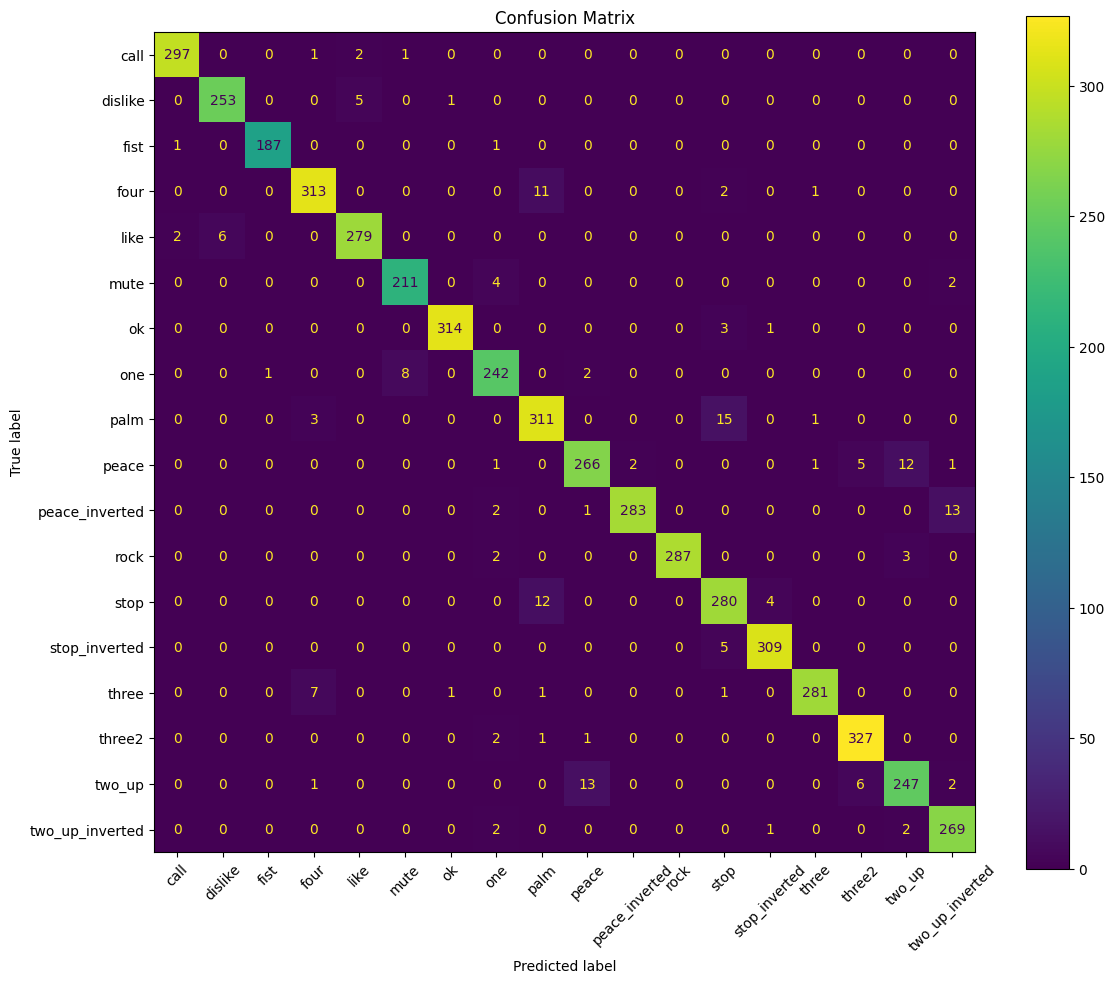

Random Forest - Accuracy : 0.965141187925998
🏃 View run Random Forest at: http://127.0.0.1:5000/#/experiments/1/runs/1ba121b079184baf931de836f69726e2
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


2026/02/28 13:46:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/28 13:46:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


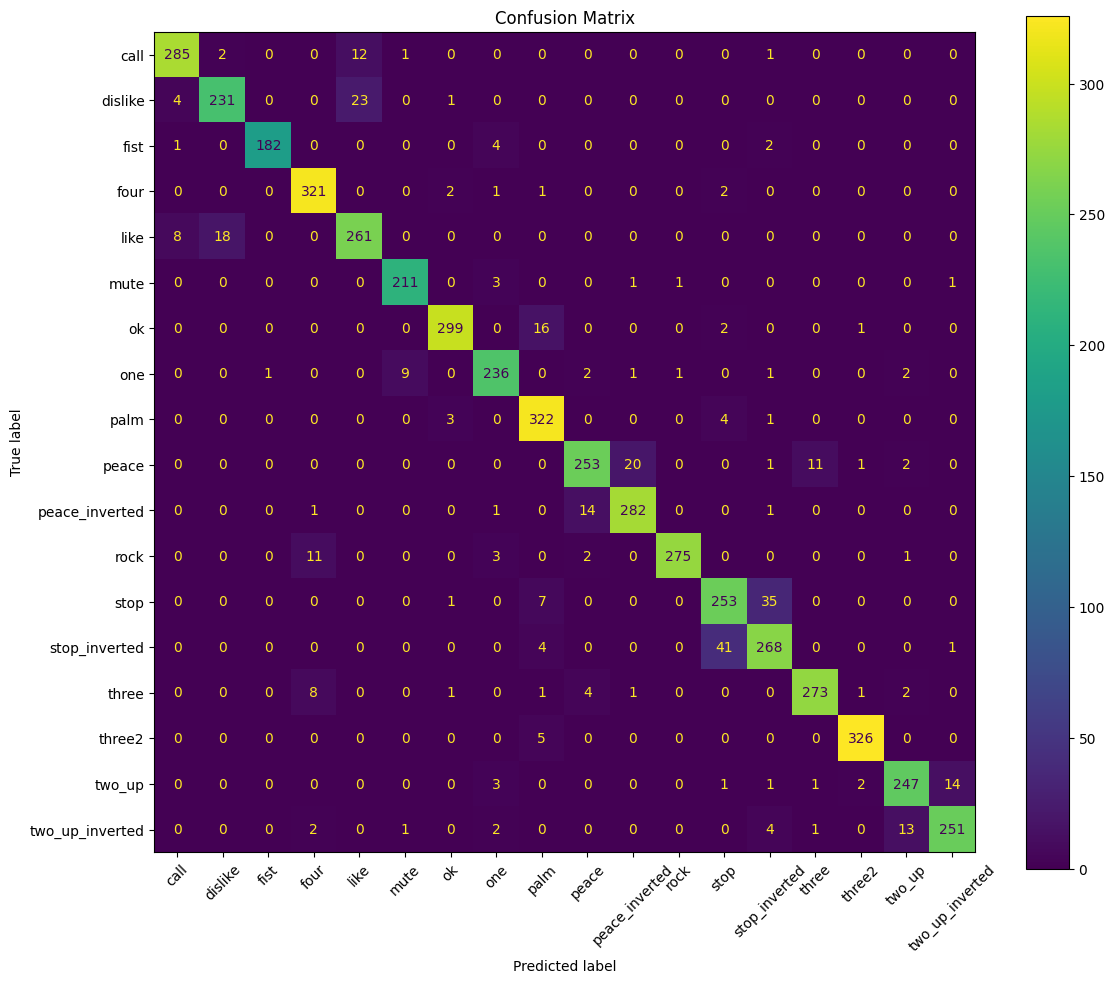

KNN - Accuracy : 0.9300876338851023
🏃 View run KNN at: http://127.0.0.1:5000/#/experiments/1/runs/e002fba3f168422b878773079ba13b5a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


2026/02/28 13:46:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/28 13:46:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


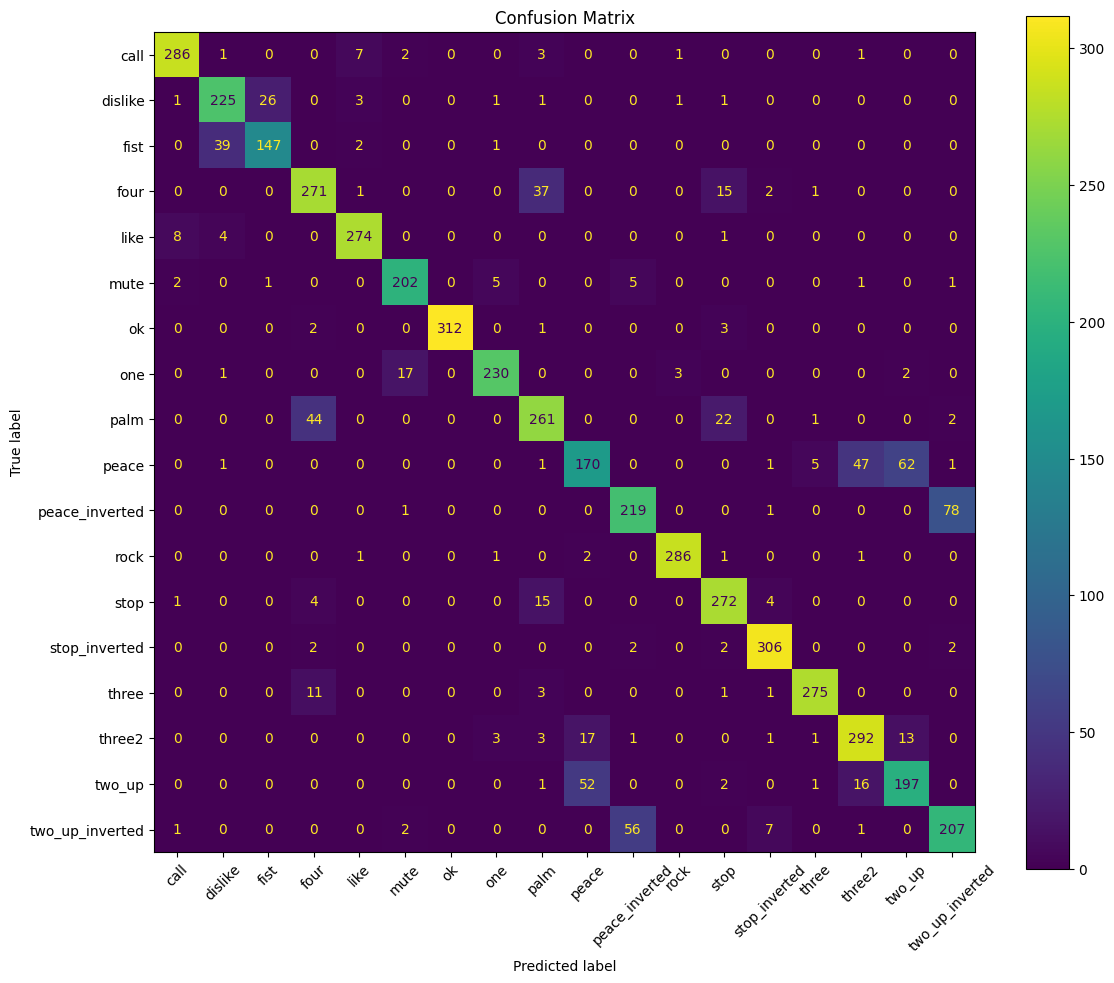

Logistic Regression - Accuracy : 0.8630963972736124
🏃 View run Logistic Regression at: http://127.0.0.1:5000/#/experiments/1/runs/5bf1eba718c44308aaca3aea41462089
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [38]:
models_mlflow= {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=1000, random_state=42))
    ])
}


all_results = {}

for name, model in models_mlflow.items():
    with mlflow.start_run(run_name=name):

        mlflow.set_tag("model_type", name)

        log_dataset(df)

        log_model_params(name, model.get_params())
        
        trained_model = train_and_log_model(model,X_train,y_train)

        y_pred = trained_model.predict(X_test)

        metrics = log_metrics(y_test, y_pred)

        all_results[name] = metrics

        log_classification_report(y_test,y_pred,le)

        log_confusion_matrix(y_test,y_pred,le)

        print(f"{name} - Accuracy : {metrics['accuracy']}")


## **Comparison Chart**

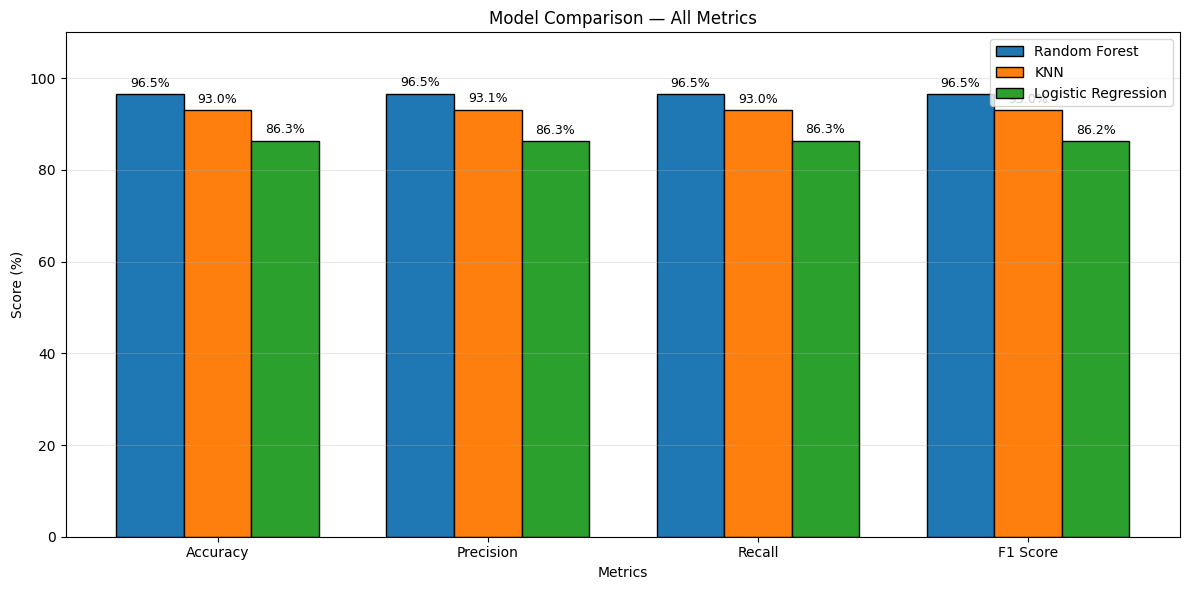

🏃 View run Model Comparison Chart at: http://127.0.0.1:5000/#/experiments/1/runs/cd6c95029e5e41819d502473122bb676
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [39]:
with mlflow.start_run(run_name = "Model Comparison Chart"):
     log_comparison_chart(all_results)

## **Register The best Model**

In [40]:

best_run = None
best_accuracy = 0

experiment = mlflow.get_experiment_by_name("Hand-Gesture-Classification")
runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

for _, run in runs.iterrows():
    if run["metrics.accuracy"] is not None and run["metrics.accuracy"] > best_accuracy:
        best_accuracy = run["metrics.accuracy"]
        best_run = run

print(f"Best model: {best_run['tags.model_type']} with accuracy: {best_accuracy*100:.2f}%")
print(f"Run ID: {best_run['run_id']}")

model_uri = f"runs:/{best_run['run_id']}/model"
model_name = "Hand-Gesture-Classifier"

result = mlflow.register_model(model_uri, model_name)

print(f"\nModel registered!")
print(f"Name: {result.name}")
print(f"Version: {result.version}")


Best model: Random Forest with accuracy: 96.51%
Run ID: 1ba121b079184baf931de836f69726e2


Successfully registered model 'Hand-Gesture-Classifier'.
2026/02/28 14:07:22 WARNING mlflow.tracking._model_registry.fluent: Run with id 1ba121b079184baf931de836f69726e2 has no artifacts at artifact path 'model', registering model based on models:/m-27c8facc9671450a8424d0e3a5860834 instead
2026/02/28 14:07:23 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Hand-Gesture-Classifier, version 1
Created version '1' of model 'Hand-Gesture-Classifier'.



Model registered!
Name: Hand-Gesture-Classifier
Version: 1


## **Add description and tag to the registered model**

In [41]:
from mlflow import MlflowClient

client = MlflowClient()

client.update_registered_model(
    name="Hand-Gesture-Classifier",
    description="Hand gesture classification using hand landmarks. Best model: Random Forest with 96.51% accuracy on 18 gesture classes."
)


client.update_model_version(
    name="Hand-Gesture-Classifier",
    version=result.version,
    description="Random Forest (n_estimators=100) trained on 20540 samples with 63 features (x,y,z coordinates of 21 hand landmarks)."
)

print(f"Model '{result.name}' version {result.version} updated with descriptions!")


Model 'Hand-Gesture-Classifier' version 1 updated with descriptions!


## **Set model version alias**

In [43]:
client.set_registered_model_alias(
    name="Hand-Gesture-Classifier",
    alias="best_one",
    version=result.version
)

print(f"Version {result.version} is now aliased as 'best_one'")


Version 1 is now aliased as 'best_one'


## **Load model from registry**

In [44]:
# Load the model directly from the registry using the alias
loaded_model = mlflow.sklearn.load_model("models:/Hand-Gesture-Classifier@best_one")

# Test it
test_sample = X_test.iloc[0:1]
prediction = loaded_model.predict(test_sample)[0]
gesture = le.inverse_transform([prediction])[0]

print(f"Loaded model from registry and predicted: {gesture}")
print("Registry is working!")


Loaded model from registry and predicted: palm
Registry is working!
